# **Modelling Random Forest**

## 1. Import Library & Konfigurasi Path


In [15]:
import os
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')

import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

RANDOM = 42
TARGET_REG = 'ISPU PM2.5'
TARGET_CAT = 'kategori_pm25'
sns.set_theme(style='whitegrid', palette='Set2')

## 2. Load Dataset


In [16]:
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == 'notebooks' else CURRENT_DIR
DATA_PATH = PROJECT_ROOT / 'data' / 'final for modelling' / 'dataset_final_new.csv'
OUTPUT_DIR = PROJECT_ROOT / 'notebooks' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f': {DATA_PATH}')

df_raw = pd.read_csv(DATA_PATH, parse_dates=['tanggal'])

print('Path dataset:', DATA_PATH)
print('Shape dataset:', df_raw.shape)
display(df_raw.head())

Path dataset: c:\Users\User\Air Pollution - Daming Project\data\final for modelling\dataset_final_new.csv
Shape dataset: (7672, 12)


,tanggal,ISPU PM2.5,kategori_pm25,bulan,hari_minggu,temp,humidity,visibility,windgust,solarenergy,precip,station
0,2022-01-01,74.0,Sedang,1,5,28.6,77.2,6.7,37.1,20.6,0.496,bundaran hi
1,2022-01-01,73.0,Sedang,1,5,28.3,77.8,6.8,37.1,20.6,0.502,jagakarsa
2,2022-01-01,69.0,Sedang,1,5,28.3,79.3,7.5,37.1,20.6,0.645,kebun jeruk
3,2022-01-01,76.0,Sedang,1,5,28.6,76.9,6.7,34.9,21.0,0.262,kelapa gading
4,2022-01-01,87.0,Sedang,1,5,28.5,76.8,6.2,34.9,21.0,0.451,lubang buaya


## 3. Cek Struktur Data, Missing Value, Target & Distribusi Kategori PM2.5


In [17]:
print('Informasi kolom dan tipe data:')
display(df_raw.dtypes.to_frame('dtype'))

print('\nMissing value per kolom:')
display(df_raw.isna().sum().to_frame('missing'))

print('\nRange tanggal:', df_raw['tanggal'].min().date(), 'sampai', df_raw['tanggal'].max().date())
print('Jumlah tanggal unik:', df_raw['tanggal'].nunique())

print('\nStatistik target ISPU PM2.5:')
display(df_raw['ISPU PM2.5'].describe().to_frame('nilai'))

print('\nDistribusi kategori PM2.5:')
display(df_raw['kategori_pm25'].value_counts().to_frame('jumlah'))

Informasi kolom dan tipe data:


,dtype
tanggal,datetime64[us]
ISPU PM2.5,float64
kategori_pm25,str
bulan,int64
hari_minggu,int64
temp,float64
humidity,float64
visibility,float64
windgust,float64
solarenergy,float64



Missing value per kolom:


,missing
tanggal,0
ISPU PM2.5,0
kategori_pm25,0
bulan,0
hari_minggu,0
temp,0
humidity,0
visibility,0
windgust,0
solarenergy,0



Range tanggal: 2022-01-01 sampai 2024-12-31
Jumlah tanggal unik: 1096

Statistik target ISPU PM2.5:


,nilai
count,7672.000000
mean,71.916835
std,22.823113
min,0.000000
25%,62.257781
50%,74.000000
75%,85.708333
max,224.875000



Distribusi kategori PM2.5:


,jumlah
kategori_pm25,
Sedang,6098
Baik,1023
Tidak Sehat,548
Sangat Tidak Sehat,3


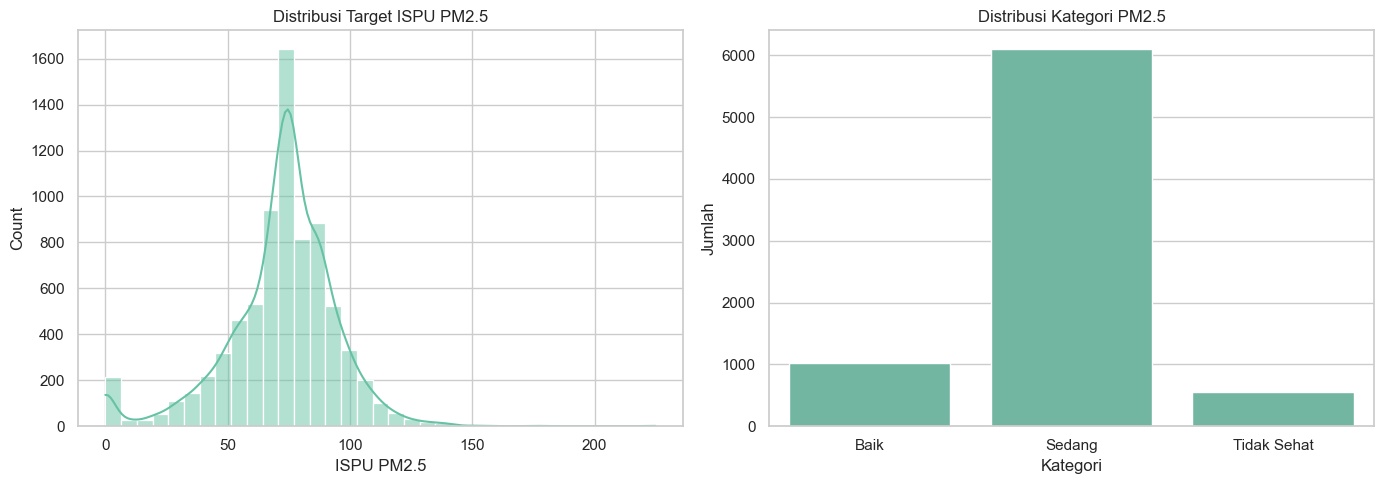

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_raw['ISPU PM2.5'], bins=35, kde=True, ax=axes[0])
axes[0].set_title('Distribusi Target ISPU PM2.5')
axes[0].set_xlabel('ISPU PM2.5')

sns.countplot(data=df_raw, x='kategori_pm25', order=['Baik', 'Sedang', 'Tidak Sehat'], ax=axes[1])
axes[1].set_title('Distribusi Kategori PM2.5')
axes[1].set_xlabel('Kategori')
axes[1].set_ylabel('Jumlah')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distribusi_target_pm25_modelling.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Engineering & Verifikasi Fitur untuk Random Forest

Section ini melakukan feature engineering lengkap pada `df_raw` (cyclical, is_weekend, musim Jakarta, lag-1 cuaca, lag/rolling PM2.5 per stasiun) sekaligus memverifikasi fitur yang akan dipakai pipeline modelling.


In [ ]:
import time
from sklearn.metrics import recall_score
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GridSearchCV, PredefinedSplit

TARGET = TARGET_REG          # 'ISPU PM2.5'
CATEGORY_COL = TARGET_CAT        # 'kategori_pm25'
DIR_OUTPUT = OUTPUT_DIR
RANDOM = RANDOM
WEATHER_COLS = ['temp', 'humidity', 'visibility', 'windgust', 'solarenergy', 'precip']


# Feature engineering untuk modelling (tanpa data leakage)
def build_modelling_features(data):
    required_cols = ['tanggal', 'bulan', 'hari_minggu', TARGET] + WEATHER_COLS
    missing_cols = [k for k in required_cols if k not in data.columns]
    if missing_cols:
        raise KeyError(f'Kolom wajib tidak ditemukan: {missing_cols}')

    result = data.copy()
    result['tanggal'] = pd.to_datetime(result['tanggal'])
   
    # Buang baris jika ada tanpa data cuaca sama sekali 
    no_weather_mask = result[WEATHER_COLS].isna().all(axis=1)
    if no_weather_mask.any():
        result = result[~no_weather_mask].reset_index(drop=True)
    
    result = result.sort_values(['station', 'tanggal']).reset_index(drop=True)

    def add_col(col_name, value):
        if col_name not in result.columns:
            result[col_name] = value

    # Fitur siklus waktu
    add_col('bulan_sin', np.sin(2 * np.pi * result['bulan'] / 12))
    add_col('bulan_cos', np.cos(2 * np.pi * result['bulan'] / 12))
    add_col('hari_minggu_sin', np.sin(2 * np.pi * result['hari_minggu'] / 7))
    add_col('hari_minggu_cos', np.cos(2 * np.pi * result['hari_minggu'] / 7))

    # Weekend & musim (konteks Jakarta: musim hujan Nov-Apr, kemarau Mei-Okt)
    add_col('is_weekend', result['hari_minggu'].isin([5, 6]).astype(int))
    add_col('musim_hujan', result['bulan'].isin([11, 12, 1, 2, 3, 4]).astype(int))
    add_col('musim_kemarau', result['bulan'].isin([5, 6, 7, 8, 9, 10]).astype(int))

    # Lag-1 cuaca per stasiun (shift(1) agar tidak ada kebocoran target)
    for kolom in ['precip', 'humidity', 'windgust', 'visibility', 'temp']:
        add_col(f'{kolom}_lag_1', result.groupby('station')[kolom].shift(1))

    # Historis PM2.5 per stasiun (lag & rolling statistics)
    for jeda in [1, 2, 7, 14]:
        add_col(f'pm25_lag_{jeda}', result.groupby('station')[TARGET].shift(jeda))
    pm25_shift = result.groupby('station')[TARGET].shift(1)
    for window in [3, 7, 14]:
        per_stasiun = pm25_shift.groupby(result['station'])
        add_col(f'pm25_roll_{window}_mean', per_stasiun.rolling(window).mean().reset_index(level=0, drop=True))
        add_col(f'pm25_roll_{window}_std', per_stasiun.rolling(window).std().reset_index(level=0, drop=True))

    result = result.sort_values(['tanggal', 'station']).reset_index(drop=True)
    return result


df = build_modelling_features(df_raw)

NON_FEATURE_COLS = ['tanggal', TARGET, CATEGORY_COL, 'station']
FEATURE_LIST = [k for k in df.columns if k not in NON_FEATURE_COLS]

print('Shape dataset final yang dipakai modelling:', df.shape)
print('Rentang tanggal:', df['tanggal'].min().date(), 'sampai', df['tanggal'].max().date())
print('Jumlah fitur modelling:', len(FEATURE_LIST))
print('\nStruktur data (tipe):')
display(df[FEATURE_LIST].dtypes.to_frame('tipe'))

Shape dataset final yang dipakai modelling: (7672, 34)
Rentang tanggal: 2022-01-01 sampai 2024-12-31
Jumlah fitur modelling: 30

Struktur data (tipe):


,tipe
bulan,int64
hari_minggu,int64
temp,float64
humidity,float64
visibility,float64
windgust,float64
solarenergy,float64
precip,float64
bulan_sin,float64
bulan_cos,float64


In [20]:
# Verifikasi fitur yang diminta sudah ada + ringkasan missing value
requested_features = ['is_weekend', 'bulan_sin', 'bulan_cos', 'musim_hujan', 'musim_kemarau',
                 'precip_lag_1', 'humidity_lag_1', 'windgust_lag_1', 'visibility_lag_1', 'temp_lag_1']
feature_status = pd.DataFrame({
    'fitur': requested_features,
    'tersedia': [f in df.columns for f in requested_features],
})
print('Status fitur yang diminta:')
display(feature_status)

print('Target bocor ke fitur?', TARGET in FEATURE_LIST, '|', CATEGORY_COL in FEATURE_LIST)

missing_features = df[FEATURE_LIST].isna().sum()
n_station = df['station'].nunique()
expected_warmup = {
    **{f'{col}_lag_1': n_station for col in ['precip', 'humidity', 'windgust', 'visibility', 'temp']},
    **{f'pm25_lag_{lag}': lag * n_station for lag in [1, 2, 7, 14]},
    **{f'pm25_roll_{window}_{stat}': window * n_station
       for window in [3, 7, 14] for stat in ['mean', 'std']},
}
missing_report = missing_features[missing_features > 0].to_frame('missing')
missing_report['expected_warmup'] = missing_report.index.map(expected_warmup).fillna(0).astype(int)
missing_report['sesuai_warmup'] = missing_report['missing'] == missing_report['expected_warmup']

print('\nFitur turunan dengan missing value struktural akibat lag/rolling:')
print('Nilai ini normal pada baris awal tiap stasiun yang belum memiliki riwayat; pipeline akan mengimputasi median dari data train.')
display(missing_report)

Status fitur yang diminta:


,fitur,tersedia
0,is_weekend,True
1,bulan_sin,True
2,bulan_cos,True
3,musim_hujan,True
4,musim_kemarau,True
5,precip_lag_1,True
6,humidity_lag_1,True
7,windgust_lag_1,True
8,visibility_lag_1,True
9,temp_lag_1,True


Target bocor ke fitur? False | False

Fitur turunan dengan missing value struktural akibat lag/rolling:
Nilai ini normal pada baris awal tiap stasiun yang belum memiliki riwayat; pipeline akan mengimputasi median dari data train.


,missing,expected_warmup,sesuai_warmup
precip_lag_1,7,7,True
humidity_lag_1,7,7,True
windgust_lag_1,7,7,True
visibility_lag_1,7,7,True
temp_lag_1,7,7,True
pm25_lag_1,7,7,True
pm25_lag_2,14,14,True
pm25_lag_7,49,49,True
pm25_lag_14,98,98,True
pm25_roll_3_mean,21,21,True


## 5. Time-based Split 70/15/15 (Train / Validation / Test)


In [21]:
def time_based_split(data, date_col='tanggal', train_size=0.70, val_size=0.15):
    unique_dates = np.array(sorted(data[date_col].unique()))
    n = len(unique_dates)
    train_cutoff = pd.Timestamp(unique_dates[int(n * train_size)])
    val_cutoff = pd.Timestamp(unique_dates[int(n * (train_size + val_size))])
    train_mask = data[date_col] < train_cutoff
    val_mask = (data[date_col] >= train_cutoff) & (data[date_col] < val_cutoff)
    test_mask = data[date_col] >= val_cutoff
    return train_mask, val_mask, test_mask, train_cutoff, val_cutoff


train_mask, val_mask, test_mask, train_cutoff, val_cutoff = time_based_split(df)

X_train, y_train = df.loc[train_mask, FEATURE_LIST], df.loc[train_mask, TARGET]
X_val, y_val = df.loc[val_mask, FEATURE_LIST], df.loc[val_mask, TARGET]
X_test, y_test = df.loc[test_mask, FEATURE_LIST], df.loc[test_mask, TARGET]

# Gabungan train+validation untuk retrain model final 
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

split_info = pd.DataFrame([
    {'subset': 'Train', 'baris': int(train_mask.sum()),
     'mulai': df.loc[train_mask, 'tanggal'].min().date(), 'akhir': df.loc[train_mask, 'tanggal'].max().date()},
    {'subset': 'Validation', 'baris': int(val_mask.sum()),
     'mulai': df.loc[val_mask, 'tanggal'].min().date(), 'akhir': df.loc[val_mask, 'tanggal'].max().date()},
    {'subset': 'Test', 'baris': int(test_mask.sum()),
     'mulai': df.loc[test_mask, 'tanggal'].min().date(), 'akhir': df.loc[test_mask, 'tanggal'].max().date()},
])
print('Train berakhir sebelum:', train_cutoff.date(), '| Validation berakhir sebelum:', val_cutoff.date())
display(split_info)

Train berakhir sebelum: 2024-02-07 | Validation berakhir sebelum: 2024-07-20


,subset,baris,mulai,akhir
0,Train,5369,2022-01-01,2024-02-06
1,Validation,1148,2024-02-07,2024-07-19
2,Test,1155,2024-07-20,2024-12-31


## 6. Fungsi Evaluasi Lengkap (MAE/RMSE/R²/MAPE) & Pipeline RF Final


In [22]:
def safe_mape(y_true, y_pred, epsilon=1.0):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.abs(y_true) > epsilon
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


def compute_regression_metrics(y_true, y_pred):
    return {
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(mean_squared_error(y_true, y_pred) ** 0.5),
        'R2': float(r2_score(y_true, y_pred)),
        'MAPE': safe_mape(y_true, y_pred),
    }


ISPU_CATEGORY_ORDER = ['Baik', 'Sedang', 'Tidak Sehat', 'Sangat Tidak Sehat', 'Berbahaya']


def to_ispu_category(value):
    if value <= 50:
        return "Baik"
    elif value <= 100:
        return "Sedang"
    elif value < 200:
        return "Tidak Sehat"
    elif value < 300:
        return "Sangat Tidak Sehat"
    else:
        return "Berbahaya"


def build_rf_pipeline(**parameter_rf):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestRegressor(random_state=RANDOM, n_jobs=-1, **parameter_rf)),
    ])

## 7. Hyperparameter Tuning Random Forest dengan **Optuna**


In [23]:
N_TRIALS = 30

use_optuna = True
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except Exception as err:
    use_optuna = False
    print('Optuna tidak tersedia (', err, ') -> fallback ke Randomized Search.')


def sample_params_from_trial(trial):
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 400, step=50),
        max_depth=trial.suggest_categorical('max_depth', [None, 8, 12, 16, 20, 24, 32]),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
        max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.7, 0.9, 1.0]),
        bootstrap=bootstrap,
    )
    if bootstrap:
        params['max_samples'] = trial.suggest_float('max_samples', 0.5, 1.0)
    return params


def evaluate_params_on_val(params):
    model = build_rf_pipeline(**params)
    model.fit(X_train, y_train)
    return float(mean_squared_error(y_val, model.predict(X_val)) ** 0.5)


trial_records = []
optuna_start_time = time.time()

if use_optuna:
    def objective(trial):
        params = sample_params_from_trial(trial)
        rmse = evaluate_params_on_val(params)
        trial.set_user_attr('parameter', params)
        return rmse

    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    best_optuna_params = dict(study.best_params)
    if not best_optuna_params.get('bootstrap', True):
        best_optuna_params.pop('max_samples', None)
    
    for trial in study.trials:
        row = dict(trial.user_attrs.get('parameter', {})); row['val_RMSE'] = trial.value
        trial_records.append(row)
    optuna_method = 'Optuna TPE'
    val_rmse_optuna = float(study.best_value)

else:
    rng = np.random.RandomState(RANDOM)
    search_space = {'n_estimators': [100, 150, 200, 250, 300, 350, 400], 'max_depth': [None, 8, 12, 16, 20, 24, 32],
             'min_samples_split': list(range(2, 21)), 'min_samples_leaf': list(range(1, 11)),
             'max_features': ['sqrt', 'log2', 0.5, 0.7, 0.9, 1.0], 'bootstrap': [True, False]}
    val_rmse_optuna = np.inf; best_optuna_params = None
    
    for _ in range(N_TRIALS):
        params = {k: (v[rng.randint(len(v))] if isinstance(v, list) else v) for k, v in search_space.items()}
        
        if params['bootstrap']:
            params['max_samples'] = float(rng.uniform(0.5, 1.0))
        rmse = evaluate_params_on_val(params)
        row = dict(params); row['val_RMSE'] = rmse; trial_records.append(row)
        
        if rmse < val_rmse_optuna:
            val_rmse_optuna = rmse; best_optuna_params = dict(params)
    optuna_method = 'Randomized Search'

waktu_optuna = time.time() - optuna_start_time
optuna_tuning_table = pd.DataFrame(trial_records).sort_values('val_RMSE').reset_index(drop=True)

optuna_tuning_table.to_csv(DIR_OUTPUT / 'hasil_tuning_random_forest_optuna.csv', index=False)

print(f'Metode tuning : {optuna_method} ({N_TRIALS} percobaan) | Waktu: {waktu_optuna:.1f} detik')
print(f'RMSE validasi terbaik : {val_rmse_optuna:.4f}')
print('Parameter terbaik     :', best_optuna_params)
print('hasil_tuning_random_forest_optuna.csv')
display(optuna_tuning_table.head(10).round(4))

Best trial: 10. Best value: 11.3717: 100%|██████████| 30/30 [02:39<00:00,  5.31s/it]

Metode tuning : Optuna TPE (30 percobaan) | Waktu: 159.4 detik
RMSE validasi terbaik : 11.3717
Parameter terbaik     : {'bootstrap': True, 'n_estimators': 200, 'max_depth': 24, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_samples': 0.9849148993894048}
hasil_tuning_random_forest_optuna.csv


,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,bootstrap,val_RMSE,max_samples
0,200,24.0,10,1,0.5,True,11.3717,0.9849
1,200,24.0,11,1,0.5,True,11.3878,0.9955
2,250,24.0,10,1,0.7,True,11.3989,0.8033
3,250,24.0,13,2,0.7,True,11.4047,0.8762
4,200,24.0,9,2,0.7,True,11.4145,0.8776
5,200,24.0,8,2,0.7,True,11.4241,0.8562
6,200,24.0,16,1,0.5,True,11.4423,0.9852
7,300,NaN,13,1,0.7,True,11.4490,0.9909
8,150,20.0,12,2,0.5,True,11.4544,0.9077
9,250,NaN,9,3,0.5,True,11.4720,0.9987


## 8. Hyperparameter Tuning Random Forest dengan **Grid Search**


In [24]:
fold_marker = np.r_[np.full(len(X_train), -1), np.zeros(len(X_val), dtype=int)]
predefined_split = PredefinedSplit(test_fold=fold_marker)

pipeline_grid = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(random_state=RANDOM, n_jobs=1)),
])

grid_parameter = [
    {'model__n_estimators': [200, 300], 'model__max_depth': [24, None], 'model__min_samples_split': [2, 15],
     'model__min_samples_leaf': [1, 2], 'model__max_features': [0.7, 0.9], 'model__bootstrap': [True],
     'model__max_samples': [0.6, 1.0]},
    {'model__n_estimators': [200, 300], 'model__max_depth': [24, None], 'model__min_samples_split': [2, 15],
     'model__min_samples_leaf': [1, 2], 'model__max_features': [0.7, 0.9], 'model__bootstrap': [False]},
]

pencarian_grid = GridSearchCV(pipeline_grid, grid_parameter, scoring='neg_root_mean_squared_error',
                              cv=predefined_split, n_jobs=-1, refit=False, verbose=2)
grid_start_time = time.time()
pencarian_grid.fit(X_train_val, y_train_val)
waktu_grid = time.time() - grid_start_time

n_grid_combos = len(pencarian_grid.cv_results_['params'])
best_grid_params = {k.replace('model__', ''): v for k, v in pencarian_grid.best_params_.items()}
if not best_grid_params.get('bootstrap', True):
    best_grid_params.pop('max_samples', None)
val_rmse_grid = float(-pencarian_grid.best_score_)

grid_tuning_table = pd.DataFrame(pencarian_grid.cv_results_['params'])
grid_tuning_table.columns = [c.replace('model__', '') for c in grid_tuning_table.columns]
grid_tuning_table['val_RMSE'] = -pencarian_grid.cv_results_['mean_test_score']
grid_tuning_table = grid_tuning_table.sort_values('val_RMSE').reset_index(drop=True)
grid_tuning_table.to_csv(DIR_OUTPUT / 'hasil_tuning_random_forest_gridsearch.csv', index=False)

print(f'Metode tuning : Grid Search ({n_grid_combos} kombinasi) | Waktu: {waktu_grid:.1f} detik')
print(f'RMSE validasi terbaik : {val_rmse_grid:.4f}')
print('Parameter terbaik     :', best_grid_params)
print('Disimpan : hasil_tuning_random_forest_gridsearch.csv')
display(grid_tuning_table.head(10).round(4))

Fitting 1 folds for each of 96 candidates, totalling 96 fits
Metode tuning : Grid Search (96 kombinasi) | Waktu: 511.1 detik
RMSE validasi terbaik : 11.3917
Parameter terbaik     : {'bootstrap': True, 'max_depth': None, 'max_features': 0.7, 'max_samples': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 15, 'n_estimators': 200}
Disimpan : hasil_tuning_random_forest_gridsearch.csv


,bootstrap,max_depth,max_features,max_samples,min_samples_leaf,min_samples_split,n_estimators,val_RMSE
0,True,NaN,0.7,1.0,1,15,200,11.3917
1,True,24.0,0.7,0.6,1,15,200,11.3995
2,True,24.0,0.7,1.0,1,15,200,11.4009
3,True,NaN,0.9,1.0,1,15,200,11.4131
4,True,NaN,0.7,1.0,1,15,300,11.4170
5,True,24.0,0.7,1.0,2,2,200,11.4177
6,True,24.0,0.9,1.0,1,2,200,11.4178
7,True,24.0,0.7,1.0,1,15,300,11.4181
8,True,24.0,0.9,1.0,1,2,300,11.4212
9,True,NaN,0.7,0.6,1,15,200,11.4214


## 9. Perbandingan Model & Pilih Terbaik berdasarkan val_RMSE


In [25]:
def compute_unhealthy_recall(y_true, y_pred):
    cat_actual = pd.Series(np.asarray(y_true)).map(to_ispu_category)
    cat_pred = pd.Series(np.asarray(y_pred)).map(to_ispu_category)
    return float(recall_score(cat_actual, cat_pred, labels=['Tidak Sehat'], average='macro', zero_division=0))


candidate_models = {}


def weights_from_target(y):
    # Bobot lebih besar untuk PM2.5 tinggi (percobaan menaikkan deteksi nilai tinggi)
    return np.where(np.asarray(y) > 100, 4.0, 1.0)


def fit_and_log(nama, factory, model_rf=True, use_weights=False):
    model = factory()
    fit_kwargs = {'model__sample_weight': weights_from_target(y_train.values)} if use_weights else {}
    model.fit(X_train, y_train, **fit_kwargs)
    pv = model.predict(X_val); pu = model.predict(X_test)
    candidate_models[nama] = {
        'model': model, 'factory': factory, 'pakai_bobot': use_weights, 'model_rf': model_rf,
        'validasi': compute_regression_metrics(y_val, pv),
        'uji': compute_regression_metrics(y_test, pu),
        'recall_ts_validasi': compute_unhealthy_recall(y_val, pv),
        'recall_ts_uji': compute_unhealthy_recall(y_test, pu),
    }


def log_baseline(nama, pv, pu):
    candidate_models[nama] = {
        'model': None, 'factory': None, 'pakai_bobot': False, 'model_rf': False,
        'validasi': compute_regression_metrics(y_val, pv),
        'uji': compute_regression_metrics(y_test, pu),
        'recall_ts_validasi': compute_unhealthy_recall(y_val, pv),
        'recall_ts_uji': compute_unhealthy_recall(y_test, pu),
    }


# 5. Baseline
train_mean = float(y_train.mean())
log_baseline('Baseline Mean',
               np.full(len(y_val), train_mean), np.full(len(y_test), train_mean))
log_baseline('Baseline Persistence (Lag-1)',
               X_val['pm25_lag_1'].fillna(train_mean).values,
               X_test['pm25_lag_1'].fillna(train_mean).values)

# 6. Random Forest awal
fit_and_log('Random Forest Awal', lambda: build_rf_pipeline(n_estimators=300))

# 7. Random Forest manual tuning
fit_and_log('Random Forest Manual Tuning',
                lambda: build_rf_pipeline(n_estimators=300, max_depth=None, min_samples_leaf=2, max_features=0.8))

# 8. Optuna
fit_and_log('Random Forest Optuna', lambda: build_rf_pipeline(**best_optuna_params))

# 9. Grid Search
fit_and_log('Random Forest Grid Search', lambda: build_rf_pipeline(**best_grid_params))

# Percobaan tambahan
fit_and_log('Random Forest Optuna + Log Target',
                lambda: Pipeline([('imputer', SimpleImputer(strategy='median')),
                                  ('model', TransformedTargetRegressor(
                                      regressor=RandomForestRegressor(random_state=RANDOM, n_jobs=-1, **best_optuna_params),
                                      func=np.log1p, inverse_func=np.expm1))]))
fit_and_log('Random Forest Optuna + Bobot PM2.5 Tinggi',
                lambda: build_rf_pipeline(**best_optuna_params), use_weights=True)

# Pilih model terbaik berdasarkan RMSE VALIDATION (hanya di antara model RF)
nama_model_rf = [n for n, c in candidate_models.items() if c['model_rf']]
best_model_name = min(nama_model_rf, key=lambda n: candidate_models[n]['validasi']['RMSE'])
best_model = candidate_models[best_model_name]['model']
print('Model terbaik (RMSE validation terkecil):', best_model_name)

Model terbaik (RMSE validation terkecil): Random Forest Optuna


In [26]:
# Tabel perbandingan: metrik VALIDATION & TEST, diurutkan val_RMSE, label terbaik by val_RMSE
comparison_rows = []
for nama, c in candidate_models.items():
    comparison_rows.append({
        'model': nama,
        'val_MAE': c['validasi']['MAE'], 'val_RMSE': c['validasi']['RMSE'],
        'val_R2': c['validasi']['R2'], 'val_MAPE': c['validasi']['MAPE'],
        'test_MAE': c['uji']['MAE'], 'test_RMSE': c['uji']['RMSE'],
        'test_R2': c['uji']['R2'], 'test_MAPE': c['uji']['MAPE'],
        'recall_TidakSehat_test': c['recall_ts_uji'],
    })

model_comparison_table = pd.DataFrame(comparison_rows).sort_values('val_RMSE').reset_index(drop=True).round(4)
model_comparison_table['keterangan'] = np.where(
    model_comparison_table['model'] == best_model_name, 'TERBAIK (val_RMSE)', '')
model_comparison_table.to_csv(DIR_OUTPUT / 'hasil_model_regresi_optuna_gridsearch.csv', index=False)

print('Tabel perbandingan model (diurutkan val_RMSE). Disimpan ke hasil_model_regresi_optuna_gridsearch.csv')
display(model_comparison_table)

Tabel perbandingan model (diurutkan val_RMSE). Disimpan ke hasil_model_regresi_optuna_gridsearch.csv


,model,val_MAE,val_RMSE,val_R2,val_MAPE,test_MAE,test_RMSE,test_R2,test_MAPE,recall_TidakSehat_test,keterangan
0,Random Forest Optuna,8.1522,11.3717,0.5912,13.2707,9.5237,13.8742,0.5734,17.9856,0.1316,TERBAIK (val_RMSE)
1,Random Forest Grid Search,8.1439,11.3917,0.5898,13.2366,9.4795,13.7522,0.5809,17.9207,0.1447,
2,Random Forest Optuna + Bobot PM2.5 Tinggi,8.1688,11.4387,0.5864,13.3500,9.5783,13.9858,0.5665,18.1739,0.1711,
3,Random Forest Manual Tuning,8.1666,11.4616,0.5847,13.2882,9.5007,13.8459,0.5752,17.8350,0.1184,
4,Random Forest Awal,8.2686,11.5107,0.5812,13.4088,9.5532,13.9620,0.5680,17.8700,0.1184,
5,Random Forest Optuna + Log Target,8.5834,12.2081,0.5289,13.2851,10.0092,14.6755,0.5227,17.8160,0.0921,
6,Baseline Persistence (Lag-1),8.9011,13.3193,0.4392,13.7481,10.0275,15.4914,0.4682,18.0048,0.3553,
7,Baseline Mean,13.9445,18.1754,-0.0443,22.2343,16.2002,21.3794,-0.0129,31.8024,0.0000,


### Interpretasi Hasil Perbandingan


In [27]:
# Ringkas perbandingan metode tuning Optuna vs Grid Search (informasi proses, bukan menimpa output lama)
def method_summary(method_name, n_evals, waktu_detik, rmse_val, params, nama_kandidat):
    mu = candidate_models[nama_kandidat]['uji']
    return {'metode': method_name, 'jumlah_evaluasi': int(n_evals), 'waktu_detik': round(float(waktu_detik), 1),
            'val_RMSE': round(float(rmse_val), 4), 'test_MAE': round(mu['MAE'], 4), 'test_RMSE': round(mu['RMSE'], 4),
            'test_R2': round(mu['R2'], 4), 'test_MAPE': round(mu['MAPE'], 4),
            'recall_TS_test': round(candidate_models[nama_kandidat]['recall_ts_uji'], 4), 'parameter_terbaik': str(params)}

tuning_comparison = pd.DataFrame([
    method_summary(optuna_method, N_TRIALS, waktu_optuna, val_rmse_optuna, best_optuna_params, 'Random Forest Optuna'),
    method_summary('Grid Search', n_grid_combos, waktu_grid, val_rmse_grid, best_grid_params, 'Random Forest Grid Search'),
])
best_tuning_method = tuning_comparison.loc[tuning_comparison['val_RMSE'].idxmin(), 'metode']
tuning_comparison['keterangan'] = np.where(tuning_comparison['metode'] == best_tuning_method, '<== val_RMSE terbaik', '')
tuning_comparison.to_csv(DIR_OUTPUT / 'perbandingan_tuning_optuna_gridsearch.csv', index=False)
print('Perbandingan metode tuning. Disimpan: perbandingan_tuning_optuna_gridsearch.csv')
display(tuning_comparison.drop(columns='parameter_terbaik'))
for _, b in tuning_comparison.iterrows():
    print(f"  {b['metode']:14s}: {b['parameter_terbaik']}")

Perbandingan metode tuning. Disimpan: perbandingan_tuning_optuna_gridsearch.csv


,metode,jumlah_evaluasi,waktu_detik,val_RMSE,test_MAE,test_RMSE,test_R2,test_MAPE,recall_TS_test,keterangan
0,Optuna TPE,30,159.4,11.3717,9.5237,13.8742,0.5734,17.9856,0.1316,<== val_RMSE terbaik
1,Grid Search,96,511.1,11.3917,9.4795,13.7522,0.5809,17.9207,0.1447,


  Optuna TPE    : {'bootstrap': True, 'n_estimators': 200, 'max_depth': 24, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_samples': 0.9849148993894048}
  Grid Search   : {'bootstrap': True, 'max_depth': None, 'max_features': 0.7, 'max_samples': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 15, 'n_estimators': 200}


## 10. Evaluasi Akhir Model RF Terbaik pada Test Set

Section ini menjalankan evaluasi lengkap untuk model RF terbaik (pemenang Section 9): regresi (MAE/RMSE/R²/MAPE), evaluasi khusus PM2.5 tinggi (>100), evaluasi kategori ISPU (classification report & confusion matrix), visualisasi, dan feature importance.


In [28]:
# Prediksi vs aktual pada TEST set untuk model terbaik (model dilatih pada Train)
test_pred = best_model.predict(X_test)

pred_vs_actual = df.loc[test_mask, ['tanggal', 'station', TARGET, CATEGORY_COL]].copy()
pred_vs_actual['prediksi_pm25'] = test_pred
pred_vs_actual['residual'] = pred_vs_actual[TARGET] - pred_vs_actual['prediksi_pm25']
pred_vs_actual['abs_error'] = pred_vs_actual['residual'].abs()
pred_vs_actual['kategori_aktual'] = pred_vs_actual[TARGET].map(to_ispu_category)
pred_vs_actual['kategori_prediksi'] = pred_vs_actual['prediksi_pm25'].map(to_ispu_category)
pred_vs_actual.to_csv(DIR_OUTPUT / 'prediksi_vs_aktual_pm25_model_terbaik.csv', index=False)

test_metrics_final = compute_regression_metrics(y_test, test_pred)
val_metrics_final = candidate_models[best_model_name]['validasi']
print('Evaluasi akhir model terbaik (', best_model_name, ') :')
print('  VALIDATION:', {k: round(v, 4) for k, v in val_metrics_final.items()})
print('  TEST      :', {k: round(v, 4) for k, v in test_metrics_final.items()})
print('Disimpan: prediksi_vs_aktual_pm25_model_terbaik.csv')
display(pred_vs_actual.head())

Evaluasi akhir model terbaik ( Random Forest Optuna ) :
  VALIDATION: {'MAE': 8.1522, 'RMSE': 11.3717, 'R2': 0.5912, 'MAPE': 13.2707}
  TEST      : {'MAE': 9.5237, 'RMSE': 13.8742, 'R2': 0.5734, 'MAPE': 17.9856}
Disimpan: prediksi_vs_aktual_pm25_model_terbaik.csv


,tanggal,station,ISPU PM2.5,kategori_pm25,prediksi_pm25,residual,abs_error,kategori_aktual,kategori_prediksi
6517,2024-07-20,bundaran hi,84.458333,Sedang,84.592360,-0.134027,0.134027,Sedang,Sedang
6518,2024-07-20,jagakarsa,88.125000,Sedang,84.223393,3.901607,3.901607,Sedang,Sedang
6519,2024-07-20,kebun jeruk,92.250000,Sedang,85.053306,7.196694,7.196694,Sedang,Sedang
6520,2024-07-20,kelapa gading,88.125000,Sedang,87.027789,1.097211,1.097211,Sedang,Sedang
6521,2024-07-20,lubang buaya,84.333333,Sedang,82.922908,1.410425,1.410425,Sedang,Sedang


### Evaluasi Khusus PM2.5 Tinggi (ISPU > 100)


In [29]:
high_mask = y_test.values > 100
n_high_total = int(high_mask.sum())

high_pm25_eval_rows = [
    {'keterangan': 'Jumlah data PM2.5 > 100 pada test set', 'nilai': n_high_total},
    {'keterangan': 'Total data test set', 'nilai': int(len(y_test))},
]
underestimate = False
if n_high_total > 0:
    y_true_high = y_test.values[high_mask]
    y_pred_high = test_pred[high_mask]
    actual_mean = float(y_true_high.mean()); pred_mean = float(y_pred_high.mean())
    underestimate = pred_mean < actual_mean
    high_pm25_eval_rows += [
        {'keterangan': 'MAE (PM2.5 > 100)', 'nilai': round(float(mean_absolute_error(y_true_high, y_pred_high)), 4)},
        {'keterangan': 'RMSE (PM2.5 > 100)', 'nilai': round(float(mean_squared_error(y_true_high, y_pred_high) ** 0.5), 4)},
        {'keterangan': 'MAPE (PM2.5 > 100) %', 'nilai': round(safe_mape(y_true_high, y_pred_high), 4)},
        {'keterangan': 'Rata-rata aktual (PM2.5 > 100)', 'nilai': round(actual_mean, 4)},
        {'keterangan': 'Rata-rata prediksi (PM2.5 > 100)', 'nilai': round(pred_mean, 4)},
        {'keterangan': 'Jumlah PM2.5>100 yang JUGA diprediksi >100', 'nilai': int((y_pred_high > 100).sum())},
    ]

high_pm25_eval_table = pd.DataFrame(high_pm25_eval_rows)
high_pm25_eval_table.to_csv(DIR_OUTPUT / 'evaluasi_pm25_tinggi_model_terbaik.csv', index=False)
print('Ringkasan evaluasi PM2.5 tinggi (disimpan ke evaluasi_pm25_tinggi_model_terbaik.csv):')
display(high_pm25_eval_table)

if n_high_total > 0 and underestimate:
    print(f'\n '
          f'(rata-rata prediksi {pred_mean:.1f} < rata-rata aktual {actual_mean:.1f}).')

Ringkasan evaluasi PM2.5 tinggi (disimpan ke evaluasi_pm25_tinggi_model_terbaik.csv):


,keterangan,nilai
0,Jumlah data PM2.5 > 100 pada test set,76.0000
1,Total data test set,1155.0000
2,MAE (PM2.5 > 100),18.2597
3,RMSE (PM2.5 > 100),21.8009
4,MAPE (PM2.5 > 100) %,16.3158
5,Rata-rata aktual (PM2.5 > 100),108.6376
6,Rata-rata prediksi (PM2.5 > 100),90.8580
7,Jumlah PM2.5>100 yang JUGA diprediksi >100,10.0000



 (rata-rata prediksi 90.9 < rata-rata aktual 108.6).


### Diagnosis: Mengapa PM2.5 Tinggi Sulit Diprediksi?

Recall Tidak Sehat rendah karena kejadian PM2.5 > 100 sebagian besar berupa **lonjakan mendadak** yang tidak terjelaskan oleh fitur cuaca + riwayat harian.


In [30]:
high_distribution = pd.DataFrame([
    {'subset': 'Train', '>100': int((y_train > 100).sum()), 'persen': round(100 * (y_train > 100).mean(), 2)},
    {'subset': 'Validation', '>100': int((y_val > 100).sum()), 'persen': round(100 * (y_val > 100).mean(), 2)},
    {'subset': 'Test', '>100': int((y_test > 100).sum()), 'persen': round(100 * (y_test > 100).mean(), 2)},
])
print('Sebaran data PM2.5 > 100 per subset (proporsi kecil -> data tidak seimbang):')
display(high_distribution)

if n_high_total > 0:
    detail = df.loc[test_mask][high_mask]
    print('Untuk kasus test PM2.5 > 100:')
    print(f"  Rata-rata aktual hari-H        : {detail[TARGET].mean():.1f}")
    print(f"  Rata-rata pm25_lag_1 (kemarin) : {detail['pm25_lag_1'].mean():.1f}")
    print(f"  Proporsi yang kemarinnya JUGA >100 : {(detail['pm25_lag_1'] > 100).mean():.2f}")

Sebaran data PM2.5 > 100 per subset (proporsi kecil -> data tidak seimbang):


,subset,>100,persen
0,Train,393,7.32
1,Validation,82,7.14
2,Test,76,6.58


Untuk kasus test PM2.5 > 100:
  Rata-rata aktual hari-H        : 108.6
  Rata-rata pm25_lag_1 (kemarin) : 95.6
  Proporsi yang kemarinnya JUGA >100 : 0.36


### Evaluasi Kategori ISPU (Classification Report & Confusion Matrix)


Accuracy          : 0.8545
Macro F1          : 0.5981
Weighted F1       : 0.8345
Recall Tidak Sehat: 0.1316

Classification report (5 tingkat ISPU):
                    precision    recall  f1-score   support

              Baik       0.80      0.59      0.68       158
            Sedang       0.87      0.96      0.91       921
       Tidak Sehat       0.42      0.13      0.20        76
Sangat Tidak Sehat       0.00      0.00      0.00         0
         Berbahaya       0.00      0.00      0.00         0

          accuracy                           0.85      1155
         macro avg       0.42      0.34      0.36      1155
      weighted avg       0.83      0.85      0.83      1155

Disimpan: classification_report_model_terbaik.csv


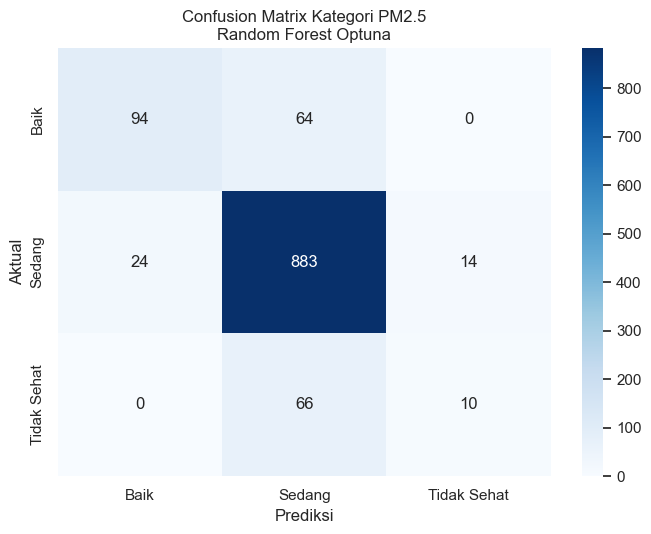

In [31]:
cat_actual = pred_vs_actual['kategori_aktual']
cat_pred = pred_vs_actual['kategori_prediksi']
present_labels = [k for k in ISPU_CATEGORY_ORDER if k in set(cat_actual) | set(cat_pred)]

accuracy = accuracy_score(cat_actual, cat_pred)
f1_macro = f1_score(cat_actual, cat_pred, labels=present_labels, average='macro', zero_division=0)
f1_weighted = f1_score(cat_actual, cat_pred, labels=present_labels, average='weighted', zero_division=0)
dict_laporan = classification_report(cat_actual, cat_pred, labels=ISPU_CATEGORY_ORDER, zero_division=0, output_dict=True)
recall_tidak_sehat = dict_laporan['Tidak Sehat']['recall']

# Simpan classification report ke CSV (nama file baru)
laporan_df = pd.DataFrame(dict_laporan).transpose().round(4)
laporan_df.to_csv(DIR_OUTPUT / 'classification_report_model_terbaik.csv')

print(f'Accuracy          : {accuracy:.4f}')
print(f'Macro F1          : {f1_macro:.4f}')
print(f'Weighted F1       : {f1_weighted:.4f}')
print(f'Recall Tidak Sehat: {recall_tidak_sehat:.4f}')
print('\nClassification report (5 tingkat ISPU):')
print(classification_report(cat_actual, cat_pred, labels=ISPU_CATEGORY_ORDER, zero_division=0))
print('Disimpan: classification_report_model_terbaik.csv')

matriks_konfusi = confusion_matrix(cat_actual, cat_pred, labels=present_labels)
plt.figure(figsize=(7, 5.5))
sns.heatmap(matriks_konfusi, annot=True, fmt='d', cmap='Blues', xticklabels=present_labels, yticklabels=present_labels)
plt.title(f'Confusion Matrix Kategori PM2.5\n{best_model_name}')
plt.xlabel('Prediksi'); plt.ylabel('Aktual')
plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'confusion_matrix_model_terbaik.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualisasi Hasil (Aktual vs Prediksi, Residual, Distribusi Error)


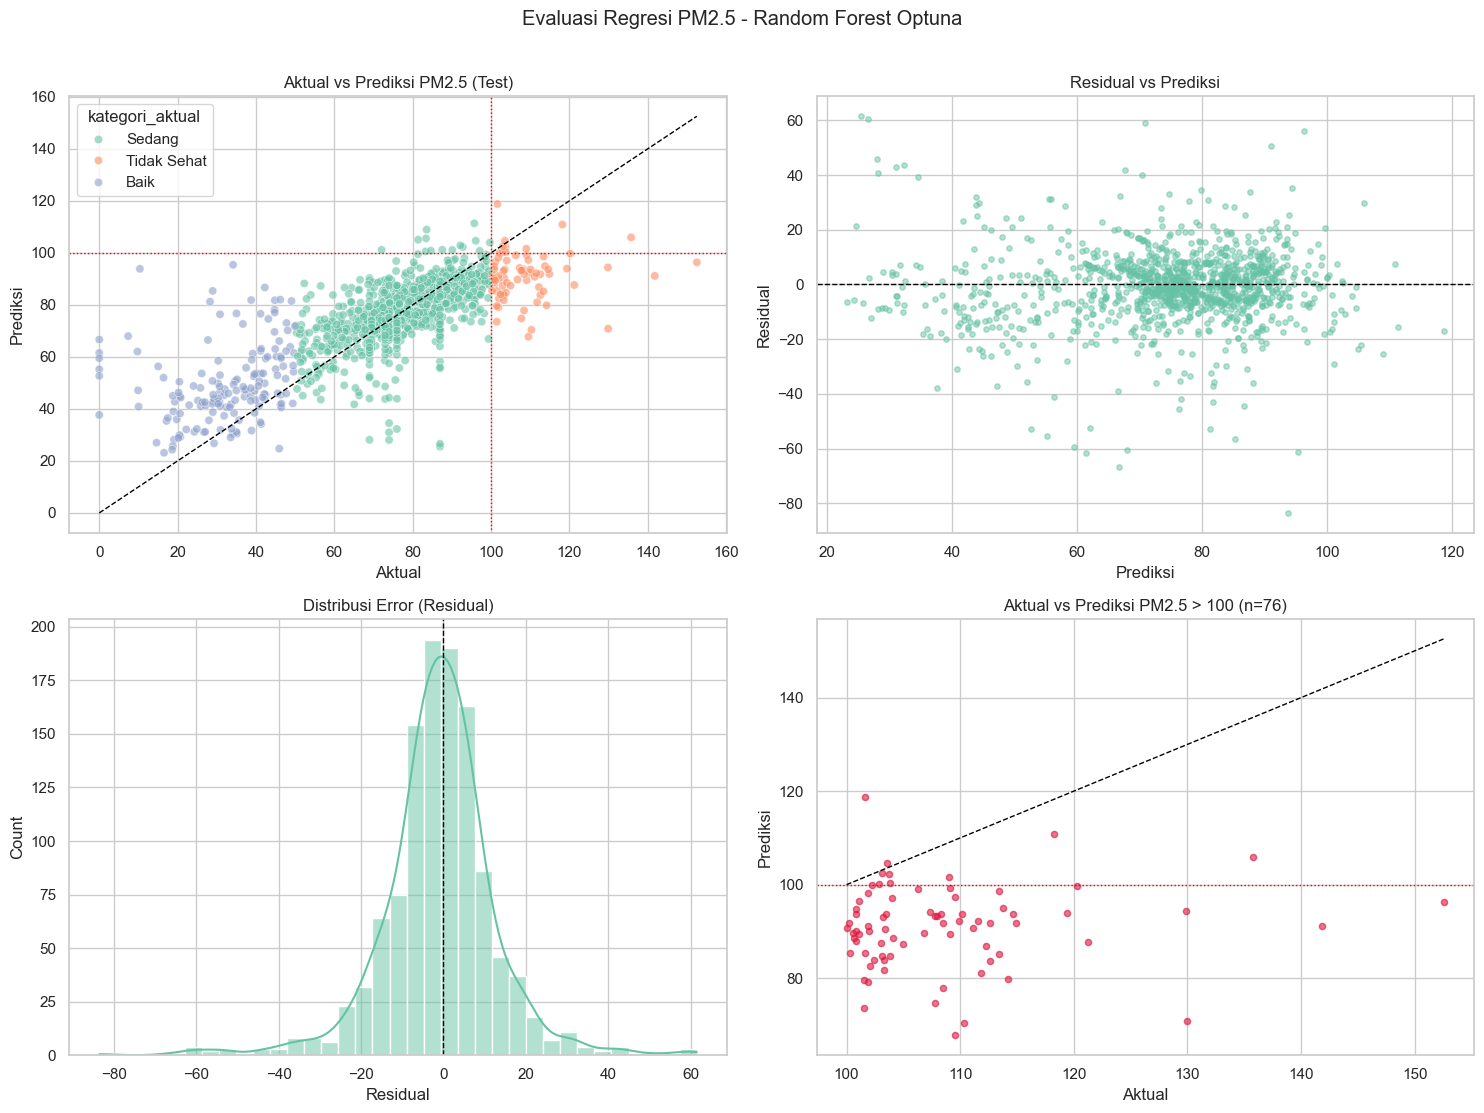

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

sns.scatterplot(data=pred_vs_actual, x=TARGET, y='prediksi_pm25', hue='kategori_aktual', alpha=0.6, ax=axes[0, 0])
lower_bound = min(pred_vs_actual[TARGET].min(), pred_vs_actual['prediksi_pm25'].min())
upper_bound = max(pred_vs_actual[TARGET].max(), pred_vs_actual['prediksi_pm25'].max())
axes[0, 0].plot([lower_bound, upper_bound], [lower_bound, upper_bound], 'k--', lw=1)
axes[0, 0].axhline(100, color='red', ls=':', lw=1); axes[0, 0].axvline(100, color='red', ls=':', lw=1)
axes[0, 0].set_title('Aktual vs Prediksi PM2.5 (Test)'); axes[0, 0].set_xlabel('Aktual'); axes[0, 0].set_ylabel('Prediksi')

axes[0, 1].scatter(pred_vs_actual['prediksi_pm25'], pred_vs_actual['residual'], alpha=0.5, s=15)
axes[0, 1].axhline(0, color='black', ls='--', lw=1)
axes[0, 1].set_title('Residual vs Prediksi'); axes[0, 1].set_xlabel('Prediksi'); axes[0, 1].set_ylabel('Residual')

sns.histplot(pred_vs_actual['residual'], kde=True, bins=35, ax=axes[1, 0])
axes[1, 0].axvline(0, color='black', ls='--', lw=1)
axes[1, 0].set_title('Distribusi Error (Residual)'); axes[1, 0].set_xlabel('Residual')

high_pm25_data = pred_vs_actual[pred_vs_actual[TARGET] > 100]
if len(high_pm25_data) > 0:
    axes[1, 1].scatter(high_pm25_data[TARGET], high_pm25_data['prediksi_pm25'], color='crimson', alpha=0.6, s=20)
    axes[1, 1].plot([100, upper_bound], [100, upper_bound], 'k--', lw=1); axes[1, 1].axhline(100, color='red', ls=':', lw=1)
    axes[1, 1].set_title(f'Aktual vs Prediksi PM2.5 > 100 (n={len(high_pm25_data)})')
    axes[1, 1].set_xlabel('Aktual'); axes[1, 1].set_ylabel('Prediksi')
else:
    axes[1, 1].text(0.5, 0.5, 'Tidak ada data PM2.5 > 100 pada test set', ha='center', va='center'); axes[1, 1].set_axis_off()

plt.suptitle(f'Evaluasi Regresi PM2.5 - {best_model_name}', y=1.01)
plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'evaluasi_regresi_pm25_model_terbaik.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Importance Random Forest


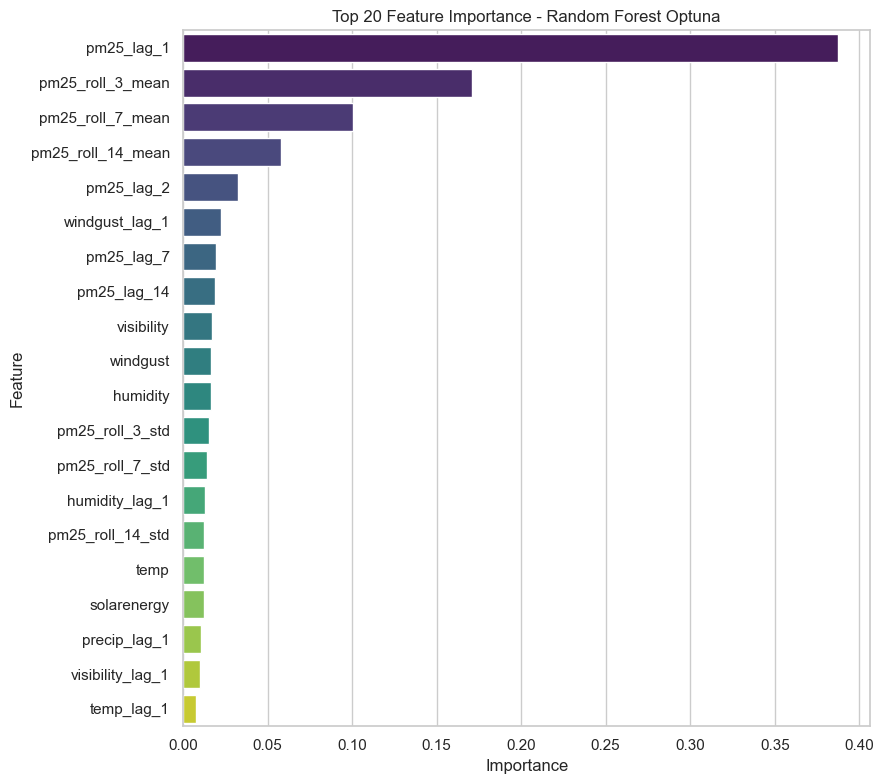

,feature,importance
0,pm25_lag_1,0.387164
1,pm25_roll_3_mean,0.171082
2,pm25_roll_7_mean,0.100257
3,pm25_roll_14_mean,0.057705
4,pm25_lag_2,0.032246
5,windgust_lag_1,0.022401
6,pm25_lag_7,0.019725
7,pm25_lag_14,0.018661
8,visibility,0.017155
9,windgust,0.016756


In [33]:
estimator_terbaik = best_model.named_steps['model']
estimator_rf = estimator_terbaik.regressor_ if hasattr(estimator_terbaik, 'regressor_') else estimator_terbaik

feature_importance_table = pd.DataFrame({
    'feature': FEATURE_LIST,
    'importance': estimator_rf.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)
feature_importance_table['importance'] = feature_importance_table['importance'].round(6)
feature_importance_table.to_csv(DIR_OUTPUT / 'feature_importance_model_terbaik.csv', index=False)

plt.figure(figsize=(9, 8))
sns.barplot(data=feature_importance_table.head(20), x='importance', y='feature', palette='viridis')
plt.title(f'Top 20 Feature Importance - {best_model_name}')
plt.xlabel('Importance'); plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'feature_importance_model_terbaik.png', dpi=150, bbox_inches='tight')
plt.show()
display(feature_importance_table.head(15))

## 11. Simpan Model Final (retrain Train + Validation) & Metadata

Best model dipilih berdasarkan **validation RMSE** dan dievaluasi pada **test**. Model dengan konfigurasi terbaik **dilatih ulang pada gabungan Train + Validation** (test **tidak** dipakai untuk training).


In [34]:
# Retrain konfigurasi terbaik pada gabungan Train + Validation
faktor_terbaik = candidate_models[best_model_name]['factory']
use_weights_best = candidate_models[best_model_name]['pakai_bobot']

model_final = faktor_terbaik()
fit_kwargs_final = {'model__sample_weight': weights_from_target(y_train_val.values)} if use_weights_best else {}
model_final.fit(X_train_val, y_train_val, **fit_kwargs_final)

path_model_final = DIR_OUTPUT / 'model_pm25_best_final.pkl'
path_metadata_final = DIR_OUTPUT / 'model_pm25_metadata_final.json'
joblib.dump(model_final, path_model_final)

param_terbaik_terpilih = (best_optuna_params if 'Optuna' in best_model_name
                          else best_grid_params if 'Grid' in best_model_name
                          else {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 0.8}
                          if 'Manual' in best_model_name else {'n_estimators': 300})

metadata_final = {
    'model_name': best_model_name,
    'algoritma': 'Random Forest Regression',
    'target': TARGET,
    'features': FEATURE_LIST,
    'jumlah_fitur': len(FEATURE_LIST),
    'data_path': str(DATA_PATH),
    'skema_split': 'time-based 70/15/15 (train/validation/test)',
    'pemilihan_model': 'berdasarkan RMSE validation terkecil (test hanya untuk evaluasi akhir)',
    'model_final_dilatih_pada': 'train + validation (test tidak dipakai untuk training)',
    'baris_train': int(train_mask.sum()), 'baris_validation': int(val_mask.sum()), 'baris_test': int(test_mask.sum()),
    'baris_train_plus_validation': int(len(X_train_val)),
    'rentang_test': [str(df.loc[test_mask, 'tanggal'].min().date()), str(df.loc[test_mask, 'tanggal'].max().date())],
    'parameter_model_terbaik': {k: (None if (isinstance(v, float) and np.isnan(v)) else v) for k, v in param_terbaik_terpilih.items()},
    'tuning': {
        'optuna': {'jumlah_evaluasi': int(N_TRIALS), 'waktu_detik': round(float(waktu_optuna), 1), 'val_RMSE': float(val_rmse_optuna)},
        'grid_search': {'jumlah_evaluasi': int(n_grid_combos), 'waktu_detik': round(float(waktu_grid), 1), 'val_RMSE': float(val_rmse_grid)},
        'metode_val_RMSE_terbaik': str(best_tuning_method),
    },
    'metrik_validation_model_terpilih': val_metrics_final,
    'metrik_test_model_terpilih': test_metrics_final,
    'evaluasi_pm25_tinggi': {b['keterangan']: b['nilai'] for b in high_pm25_eval_rows},
    'metrik_kategori_test': {'accuracy': float(accuracy), 'macro_f1': float(f1_macro),
                             'weighted_f1': float(f1_weighted), 'recall_tidak_sehat': float(recall_tidak_sehat)},
}
path_metadata_final.write_text(json.dumps(metadata_final, indent=2, ensure_ascii=False), encoding='utf-8')

output_files = [
    'hasil_model_regresi_optuna_gridsearch.csv', 'hasil_tuning_random_forest_optuna.csv',
    'hasil_tuning_random_forest_gridsearch.csv', 'perbandingan_tuning_optuna_gridsearch.csv',
    'prediksi_vs_aktual_pm25_model_terbaik.csv', 'evaluasi_pm25_tinggi_model_terbaik.csv',
    'classification_report_model_terbaik.csv', 'confusion_matrix_model_terbaik.png',
    'evaluasi_regresi_pm25_model_terbaik.png', 'feature_importance_model_terbaik.csv',
    'feature_importance_model_terbaik.png', 'model_pm25_best_final.pkl', 'model_pm25_metadata_final.json',
]
print('Model final (retrain train+validation) :', path_model_final)
print('Metadata final                         :', path_metadata_final)
print('\nFile output BARU di', DIR_OUTPUT, '(tidak menimpa output lama):')

Model final (retrain train+validation) : c:\Users\User\Air Pollution - Daming Project\notebooks\outputs\model_pm25_best_final.pkl
Metadata final                         : c:\Users\User\Air Pollution - Daming Project\notebooks\outputs\model_pm25_metadata_final.json

File output BARU di c:\Users\User\Air Pollution - Daming Project\notebooks\outputs (tidak menimpa output lama):


## 12. Eksperimen Lanjutan: Random Forest + Lag/Rolling + Weighted (Perbaikan)

Section ini mengeksplorasi varian RF dengan fitur lag/rolling eksplisit dan sample weighting untuk mencoba menaikkan recall pada kategori “Tidak Sehat”. Hasil section ini BUKAN model proposal utama, melainkan eksperimen lanjutan.


### Feature Engineering Baru (Lag, Rolling, Siklikal, Musim)

Lag & rolling dibuat **per stasiun** (`groupby('station')`). Rolling memakai `shift(1)` sebelum agregasi agar hari yang sedang diprediksi tidak ikut masuk ke statistik input (tidak ada data leakage).


In [35]:
TARGET = TARGET_REG  # 'ISPU PM2.5'

df = df_raw.copy()
df['tanggal'] = pd.to_datetime(df['tanggal'])

# Buang baris tanpa data cuaca sama sekali (2025-01-01)
WEATHER_COLS = ['temp', 'humidity', 'visibility', 'windgust', 'solarenergy', 'precip']
no_weather_mask = df[WEATHER_COLS].isna().all(axis=1)
df = df[~no_weather_mask].reset_index(drop=True)

# Rekonstruksi nama stasiun dari one-hot hanya jika dataset belum memiliki kolom station
station_cols = [c for c in df.columns if c.startswith('station_')]
if 'station' not in df.columns:
    if not station_cols:
        raise KeyError('Kolom station maupun station_* tidak ditemukan.')
    df['station'] = df[station_cols].idxmax(axis=1).str.replace('station_', '', regex=False)

# Pastikan kolom bulan & hari_minggu ada (ekstrak dari tanggal jika belum)
if 'bulan' not in df.columns:
    df['bulan'] = df['tanggal'].dt.month
if 'hari_minggu' not in df.columns:
    df['hari_minggu'] = df['tanggal'].dt.dayofweek

# Urutkan per stasiun, tanggal untuk lag yang konsisten
df = df.sort_values(['station', 'tanggal']).reset_index(drop=True)

# Fitur lag per stasiun: shift(lag) -> hanya melihat hari sebelumnya
for lag in [1, 3, 7]:
    df[f'pm25_lag_{lag}'] = df.groupby('station')[TARGET].shift(lag)

# Fitur rolling per stasiun: WAJIB pakai shift(1) dulu, baru rolling.
pm25_prev = df.groupby('station')[TARGET].shift(1)

def rolling_per_station(series, window, func):
    return series.groupby(df['station']).rolling(window).agg(func).reset_index(level=0, drop=True)

df['pm25_rolling_mean_3'] = rolling_per_station(pm25_prev, 3, 'mean')
df['pm25_rolling_mean_7'] = rolling_per_station(pm25_prev, 7, 'mean')
df['pm25_rolling_max_7'] = rolling_per_station(pm25_prev, 7, 'max')
df['pm25_rolling_std_7'] = rolling_per_station(pm25_prev, 7, 'std')

# Fitur waktu siklikal
df['bulan_sin'] = np.sin(2 * np.pi * df['bulan'] / 12)
df['bulan_cos'] = np.cos(2 * np.pi * df['bulan'] / 12)
df['hari_minggu_sin'] = np.sin(2 * np.pi * df['hari_minggu'] / 7)
df['hari_minggu_cos'] = np.cos(2 * np.pi * df['hari_minggu'] / 7)

# Musim Jakarta: Hujan (Nov-Mar), Kemarau (Mei-Okt), Transisi (April)
def assign_season(bulan):
    if bulan in [11, 12, 1, 2, 3]:
        return 'Hujan'
    if bulan == 4:
        return 'Transisi'
    return 'Kemarau'  # 5-10

df['musim'] = df['bulan'].map(assign_season)

# Hapus baris NaN akibat lag/rolling secara aman
before = len(df)
lag_rolling_features = ['pm25_lag_1', 'pm25_lag_3', 'pm25_lag_7',
                     'pm25_rolling_mean_3', 'pm25_rolling_mean_7',
                     'pm25_rolling_max_7', 'pm25_rolling_std_7']
df = df.dropna(subset=lag_rolling_features).reset_index(drop=True)
print(f'Baris setelah drop NaN lag/rolling: {len(df)} (dibuang {before - len(df)})')

# Sort balik ke (tanggal, station) untuk split waktu
df = df.sort_values(['tanggal', 'station']).reset_index(drop=True)
display(df[['tanggal', 'station', TARGET] + lag_rolling_features + ['musim']].head(10))

Baris setelah drop NaN lag/rolling: 7623 (dibuang 49)


,tanggal,station,ISPU PM2.5,pm25_lag_1,pm25_lag_3,pm25_lag_7,pm25_rolling_mean_3,pm25_rolling_mean_7,pm25_rolling_max_7,pm25_rolling_std_7,musim
0,2022-01-08,bundaran hi,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,0.000000,Hujan
1,2022-01-08,jagakarsa,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,0.000000,Hujan
2,2022-01-08,kebun jeruk,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,0.000000,Hujan
3,2022-01-08,kelapa gading,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,0.000000,Hujan
4,2022-01-08,lubang buaya,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,0.000000,Hujan
5,2022-01-08,us embassy 1,58.667845,80.154021,69.540861,69.540861,74.023749,71.462099,80.154021,3.975784,Hujan
6,2022-01-08,us embassy 2,60.124441,74.064722,76.636273,76.636273,75.779089,76.268908,76.636273,0.971955,Hujan
7,2022-01-09,bundaran hi,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,0.000000,Hujan
8,2022-01-09,jagakarsa,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,0.000000,Hujan
9,2022-01-09,kebun jeruk,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,0.000000,Hujan


### Split Time-Based 70/15/15 untuk RF Perbaikan


In [36]:
# Definisi fitur numerik & kategorikal untuk ColumnTransformer
NUMERIC_COLS = (
    ['temp', 'humidity', 'visibility', 'windgust', 'solarenergy', 'precip',
     'pm25_lag_1', 'pm25_lag_3', 'pm25_lag_7',
     'pm25_rolling_mean_3', 'pm25_rolling_mean_7', 'pm25_rolling_max_7', 'pm25_rolling_std_7',
     'bulan_sin', 'bulan_cos', 'hari_minggu_sin', 'hari_minggu_cos']
    + station_cols  # station_* one-hot sudah berupa angka 0/1
)
CATEGORICAL_COLS = ['musim']
FEATURE_LIST = NUMERIC_COLS + CATEGORICAL_COLS

# Time split 70/15/15 berbasis tanggal unik
unique_dates = np.array(sorted(df['tanggal'].unique()))
n_dates = len(unique_dates)
train_cutoff = pd.Timestamp(unique_dates[int(n_dates * 0.70)])
val_cutoff = pd.Timestamp(unique_dates[int(n_dates * 0.85)])

train_mask = df['tanggal'] < train_cutoff
val_mask = (df['tanggal'] >= train_cutoff) & (df['tanggal'] < val_cutoff)
test_mask = df['tanggal'] >= val_cutoff

X_train = df.loc[train_mask, FEATURE_LIST].copy()
y_train = df.loc[train_mask, TARGET].copy()
X_val = df.loc[val_mask, FEATURE_LIST].copy()
y_val = df.loc[val_mask, TARGET].copy()
X_test = df.loc[test_mask, FEATURE_LIST].copy()
y_test = df.loc[test_mask, TARGET].copy()

split_info = pd.DataFrame([
    {'subset': 'Train', 'baris': int(train_mask.sum()),
     'mulai': df.loc[train_mask, 'tanggal'].min().date(),
     'akhir': df.loc[train_mask, 'tanggal'].max().date()},
    {'subset': 'Validation', 'baris': int(val_mask.sum()),
     'mulai': df.loc[val_mask, 'tanggal'].min().date(),
     'akhir': df.loc[val_mask, 'tanggal'].max().date()},
    {'subset': 'Test', 'baris': int(test_mask.sum()),
     'mulai': df.loc[test_mask, 'tanggal'].min().date(),
     'akhir': df.loc[test_mask, 'tanggal'].max().date()},
])
print(f'Train berakhir sebelum: {train_cutoff.date()} | Validation berakhir sebelum: {val_cutoff.date()}')
print(f'Jumlah fitur numerik: {len(NUMERIC_COLS)} | kategorikal: {len(CATEGORICAL_COLS)}')
display(split_info)

Train berakhir sebelum: 2024-02-09 | Validation berakhir sebelum: 2024-07-21
Jumlah fitur numerik: 17 | kategorikal: 1


,subset,baris,mulai,akhir
0,Train,5334,2022-01-08,2024-02-08
1,Validation,1141,2024-02-09,2024-07-20
2,Test,1148,2024-07-21,2024-12-31


### Random Forest + Lag/Rolling (tanpa Weighting)


In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Pipeline numerik & kategorikal
numeric_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median'))])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, NUMERIC_COLS),
    ('cat', categorical_pipeline, CATEGORICAL_COLS),
])

# Parameter awal gunakan hasil Optuna terbaik jika tersedia, fallback ke konfigurasi masuk akal
try:
    rf_params = dict(best_optuna_params)
except NameError:
    rf_params = {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 1}
rf_params.setdefault('n_estimators', 300)
rf_params.setdefault('random_state', RANDOM)
rf_params.setdefault('n_jobs', -1)
print('Parameter RF perbaikan:', rf_params)

# Model 1: Random Forest + Lag/Rolling (tanpa weighting)
rf_lag = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(**rf_params)),
])
rf_lag.fit(X_train, y_train)
val_pred_lag = rf_lag.predict(X_val)
test_pred_lag = rf_lag.predict(X_test)

val_metrics_lag = compute_regression_metrics(y_val, val_pred_lag)
test_metrics_lag = compute_regression_metrics(y_test, test_pred_lag)
print('VAL  :', {k: round(v, 4) for k, v in val_metrics_lag.items()})
print('TEST :', {k: round(v, 4) for k, v in test_metrics_lag.items()})

Parameter RF perbaikan: {'bootstrap': True, 'n_estimators': 200, 'max_depth': 24, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_samples': 0.9849148993894048, 'random_state': 42, 'n_jobs': -1}
VAL  : {'MAE': 8.3028, 'RMSE': 11.5717, 'R2': 0.5762, 'MAPE': 13.523}
TEST : {'MAE': 9.5979, 'RMSE': 13.8818, 'R2': 0.5745, 'MAPE': 18.3256}


### Random Forest + Lag/Rolling + Weighted (PM2.5 > 100)


In [38]:
# Bobot 5 untuk y_train > 100, 1 lainnya
train_weights = np.where(y_train.values > 100, 5.0, 1.0).astype(np.float32)
print(f'Distribusi bobot train: y>100 = {int((train_weights == 5.0).sum())} sampel (bobot 5), '
      f'y<=100 = {int((train_weights == 1.0).sum())} sampel (bobot 1)')

rf_lag_weighted = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(**rf_params)),
])
rf_lag_weighted.fit(X_train, y_train, model__sample_weight=train_weights)
val_pred_lag_w = rf_lag_weighted.predict(X_val)
test_pred_lag_w = rf_lag_weighted.predict(X_test)

val_metrics_lag_w = compute_regression_metrics(y_val, val_pred_lag_w)
test_metrics_lag_w = compute_regression_metrics(y_test, test_pred_lag_w)
print('VAL  (weighted) :', {k: round(v, 4) for k, v in val_metrics_lag_w.items()})
print('TEST (weighted) :', {k: round(v, 4) for k, v in test_metrics_lag_w.items()})

Distribusi bobot train: y>100 = 393 sampel (bobot 5), y<=100 = 4941 sampel (bobot 1)
VAL  (weighted) : {'MAE': 8.3887, 'RMSE': 11.6557, 'R2': 0.57, 'MAPE': 13.7333}
TEST (weighted) : {'MAE': 9.7929, 'RMSE': 14.1414, 'R2': 0.5584, 'MAPE': 18.7031}


### Evaluasi RF Perbaikan


In [39]:
def evaluate_high_pm25(y_true, y_pred):
    hi = (np.asarray(y_true) > 100)
    n_actual = int(hi.sum())
    n_pred = int((np.asarray(y_pred) > 100).sum())
    if n_actual == 0:
        return {'n_aktual_PM25_gt_100': 0, 'n_prediksi_PM25_gt_100': n_pred,
                'MAE_PM25_gt_100': np.nan, 'RMSE_PM25_gt_100': np.nan,
                'MAPE_PM25_gt_100': np.nan,
                'rata_aktual_PM25_gt_100': np.nan, 'rata_prediksi_PM25_gt_100': np.nan}
    yt_h = np.asarray(y_true)[hi]; yp_h = np.asarray(y_pred)[hi]
    return {
        'n_aktual_PM25_gt_100': n_actual, 'n_prediksi_PM25_gt_100': n_pred,
        'MAE_PM25_gt_100': float(mean_absolute_error(yt_h, yp_h)),
        'RMSE_PM25_gt_100': float(mean_squared_error(yt_h, yp_h) ** 0.5),
        'MAPE_PM25_gt_100': float(safe_mape(yt_h, yp_h)),
        'rata_aktual_PM25_gt_100': float(yt_h.mean()),
        'rata_prediksi_PM25_gt_100': float(yp_h.mean()),
    }


def build_full_eval_row(nama, jenis, y_true, y_pred):
    base = compute_regression_metrics(y_true, y_pred)
    hi = evaluate_high_pm25(y_true, y_pred)
    return {
        'model': nama, 'jenis_model': jenis,
        'MAE': round(base['MAE'], 4), 'RMSE': round(base['RMSE'], 4),
        'R2': round(base['R2'], 4), 'MAPE': round(base['MAPE'], 4),
        'MAE_PM25_gt_100': round(hi['MAE_PM25_gt_100'], 4) if not np.isnan(hi['MAE_PM25_gt_100']) else np.nan,
        'RMSE_PM25_gt_100': round(hi['RMSE_PM25_gt_100'], 4) if not np.isnan(hi['RMSE_PM25_gt_100']) else np.nan,
        'jumlah_aktual_PM25_gt_100': hi['n_aktual_PM25_gt_100'],
        'jumlah_prediksi_PM25_gt_100': hi['n_prediksi_PM25_gt_100'],
        'rata_aktual_PM25_gt_100': round(hi['rata_aktual_PM25_gt_100'], 4) if not np.isnan(hi['rata_aktual_PM25_gt_100']) else np.nan,
        'rata_prediksi_PM25_gt_100': round(hi['rata_prediksi_PM25_gt_100'], 4) if not np.isnan(hi['rata_prediksi_PM25_gt_100']) else np.nan,
        'recall_Tidak_Sehat': round(compute_unhealthy_recall(y_true.values if hasattr(y_true, 'values') else y_true, y_pred), 4),
    }


rf_results_fe = pd.DataFrame([
    build_full_eval_row('Random Forest + Lag/Rolling', 'Random Forest (Perbaikan)', y_test, test_pred_lag),
    build_full_eval_row('Random Forest + Lag/Rolling + Weighted High PM2.5', 'Random Forest (Perbaikan)', y_test, test_pred_lag_w),
])
rf_results_fe.to_csv(DIR_OUTPUT / 'evaluasi_random_forest_perbaikan.csv', index=False)
print('Tabel evaluasi RF perbaikan (disimpan: evaluasi_random_forest_perbaikan.csv):')
display(rf_results_fe)

# Detail high PM2.5 (file terpisah)
high_pm25_details = pd.DataFrame([
    {**{'model': 'Random Forest + Lag/Rolling'}, **{k: round(v, 4) if isinstance(v, float) and not np.isnan(v) else v for k, v in evaluate_high_pm25(y_test, test_pred_lag).items()}},
    {**{'model': 'Random Forest + Lag/Rolling + Weighted High PM2.5'}, **{k: round(v, 4) if isinstance(v, float) and not np.isnan(v) else v for k, v in evaluate_high_pm25(y_test, test_pred_lag_w).items()}},
])
high_pm25_details.to_csv(DIR_OUTPUT / 'evaluasi_high_pm25_random_forest.csv', index=False)
print('Detail evaluasi PM2.5 > 100 (disimpan: evaluasi_high_pm25_random_forest.csv):')
display(high_pm25_details)

Tabel evaluasi RF perbaikan (disimpan: evaluasi_random_forest_perbaikan.csv):


,model,jenis_model,MAE,RMSE,R2,MAPE,MAE_PM25_gt_100,RMSE_PM25_gt_100,jumlah_aktual_PM25_gt_100,jumlah_prediksi_PM25_gt_100,rata_aktual_PM25_gt_100,rata_prediksi_PM25_gt_100,recall_Tidak_Sehat
0,Random Forest + Lag/Rolling,Random Forest (Perbaikan),9.5979,13.8818,0.5745,18.3256,18.3503,21.6267,76,20,108.6376,90.7498,0.0789
1,Random Forest + Lag/Rolling + Weighted High PM2.5,Random Forest (Perbaikan),9.7929,14.1414,0.5584,18.7031,17.5232,20.7554,76,29,108.6376,91.9399,0.1579


Detail evaluasi PM2.5 > 100 (disimpan: evaluasi_high_pm25_random_forest.csv):


,model,n_aktual_PM25_gt_100,n_prediksi_PM25_gt_100,MAE_PM25_gt_100,RMSE_PM25_gt_100,MAPE_PM25_gt_100,rata_aktual_PM25_gt_100,rata_prediksi_PM25_gt_100
0,Random Forest + Lag/Rolling,76,20,18.3503,21.6267,16.4301,108.6376,90.7498
1,Random Forest + Lag/Rolling + Weighted High PM2.5,76,29,17.5232,20.7554,15.7230,108.6376,91.9399


### Pilih RF Perbaikan Terbaik (val_RMSE) + Feature Importance + Visualisasi


val_RMSE Lag/Rolling          : 11.5717
val_RMSE Lag/Rolling + Weighted: 11.6557
RF Perbaikan terbaik (val_RMSE terkecil): Random Forest + Lag/Rolling


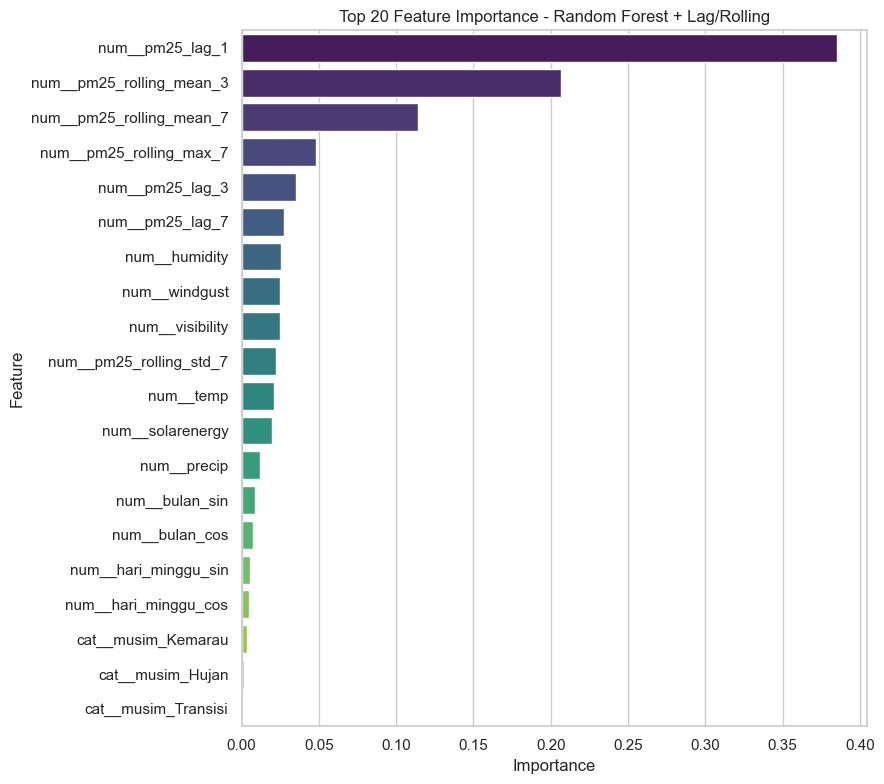

,feature,importance
0,num__pm25_lag_1,0.385291
1,num__pm25_rolling_mean_3,0.206422
2,num__pm25_rolling_mean_7,0.114357
3,num__pm25_rolling_max_7,0.048422
4,num__pm25_lag_3,0.035275
5,num__pm25_lag_7,0.027733
6,num__humidity,0.025310
7,num__windgust,0.024976
8,num__visibility,0.024928
9,num__pm25_rolling_std_7,0.022407


In [40]:
val_rmse_lag = val_metrics_lag['RMSE']
val_rmse_lag_w = val_metrics_lag_w['RMSE']
print(f'val_RMSE Lag/Rolling          : {val_rmse_lag:.4f}')
print(f'val_RMSE Lag/Rolling + Weighted: {val_rmse_lag_w:.4f}')

if val_rmse_lag <= val_rmse_lag_w:
    best_rf_model = rf_lag
    best_rf_name = 'Random Forest + Lag/Rolling'
    val_pred_best_rf = val_pred_lag
    test_pred_best_rf = test_pred_lag
else:
    best_rf_model = rf_lag_weighted
    best_rf_name = 'Random Forest + Lag/Rolling + Weighted High PM2.5'
    val_pred_best_rf = val_pred_lag_w
    test_pred_best_rf = test_pred_lag_w

print(f'RF Perbaikan terbaik (val_RMSE terkecil): {best_rf_name}')

# Feature importance (ambil nama fitur final dari ColumnTransformer)
final_features = list(best_rf_model.named_steps['preprocess'].get_feature_names_out())
feature_importance = best_rf_model.named_steps['model'].feature_importances_
feature_importance_table = pd.DataFrame({'feature': final_features, 'importance': feature_importance}).sort_values('importance', ascending=False).reset_index(drop=True)
feature_importance_table['importance'] = feature_importance_table['importance'].round(6)
feature_importance_table.to_csv(DIR_OUTPUT / 'feature_importance_random_forest_perbaikan.csv', index=False)

plt.figure(figsize=(9, 8))
sns.barplot(data=feature_importance_table.head(20), x='importance', y='feature', palette='viridis')
plt.title(f'Top 20 Feature Importance - {best_rf_name}')
plt.xlabel('Importance'); plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'feature_importance_random_forest_perbaikan.png', dpi=150, bbox_inches='tight')
plt.show()
display(feature_importance_table.head(15))

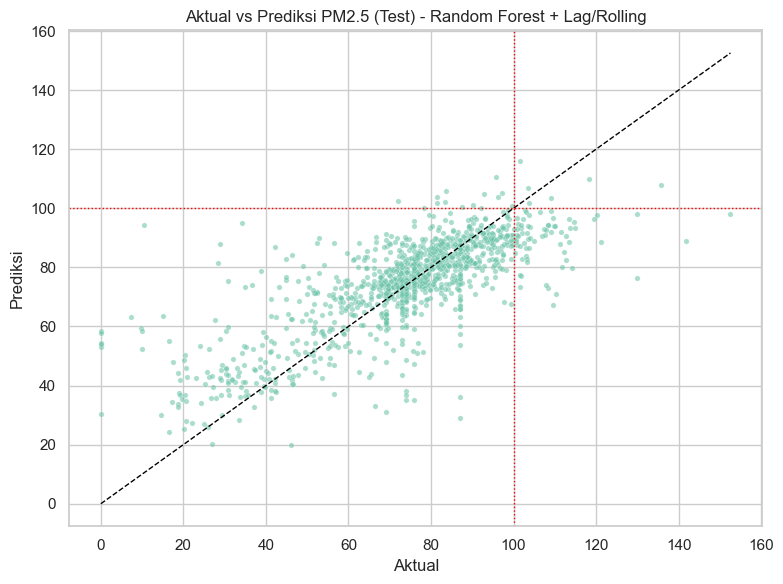

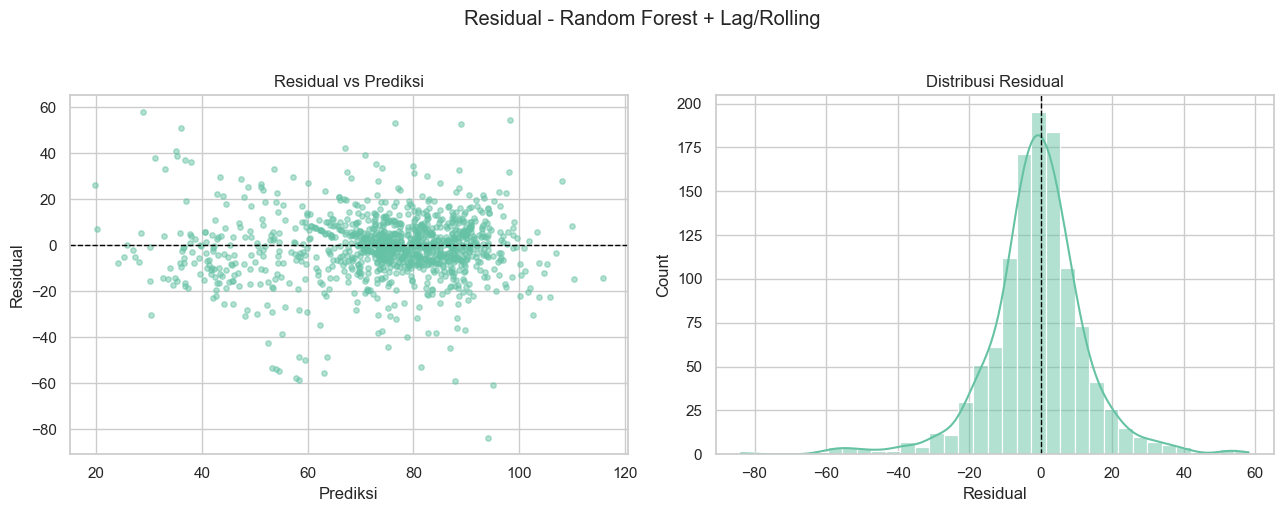

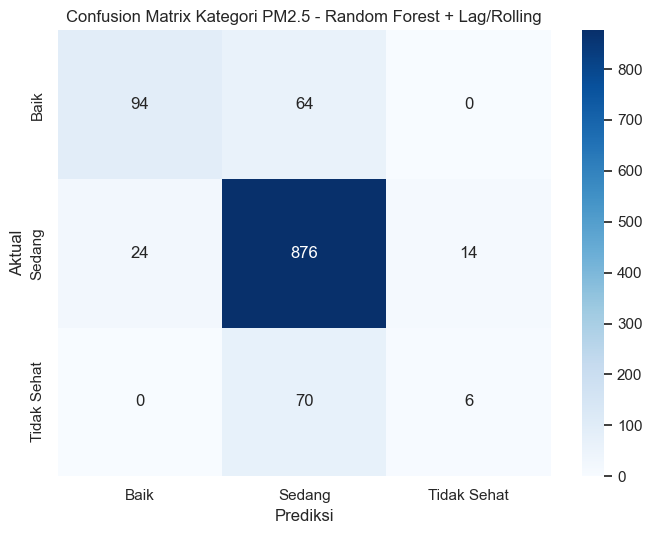

In [41]:
# Actual vs Predicted scatter
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=test_pred_best_rf, alpha=0.55, s=15)
mn = float(min(y_test.min(), test_pred_best_rf.min()))
mx = float(max(y_test.max(), test_pred_best_rf.max()))
plt.plot([mn, mx], [mn, mx], 'k--', lw=1)
plt.axhline(100, color='red', ls=':', lw=1); plt.axvline(100, color='red', ls=':', lw=1)
plt.title(f'Aktual vs Prediksi PM2.5 (Test) - {best_rf_name}')
plt.xlabel('Aktual'); plt.ylabel('Prediksi')
plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'actual_vs_predicted_random_forest_perbaikan.png', dpi=150, bbox_inches='tight')
plt.show()

# Residual: scatter vs prediksi + distribusi
rf_residual = y_test.values - test_pred_best_rf
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(test_pred_best_rf, rf_residual, alpha=0.5, s=15)
axes[0].axhline(0, color='black', ls='--', lw=1)
axes[0].set_title('Residual vs Prediksi'); axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Residual')
sns.histplot(rf_residual, kde=True, bins=35, ax=axes[1])
axes[1].axvline(0, color='black', ls='--', lw=1)
axes[1].set_title('Distribusi Residual'); axes[1].set_xlabel('Residual')
plt.suptitle(f'Residual - {best_rf_name}', y=1.02)
plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'residual_random_forest_perbaikan.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrix kategori ISPU
cat_actual = pd.Series(y_test.values).map(to_ispu_category)
cat_pred = pd.Series(test_pred_best_rf).map(to_ispu_category)
present_labels = [k for k in ISPU_CATEGORY_ORDER if k in set(cat_actual) | set(cat_pred)]
cm = confusion_matrix(cat_actual, cat_pred, labels=present_labels)
plt.figure(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=present_labels, yticklabels=present_labels)
plt.title(f'Confusion Matrix Kategori PM2.5 - {best_rf_name}')
plt.xlabel('Prediksi'); plt.ylabel('Aktual')
plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'confusion_matrix_random_forest_perbaikan.png', dpi=150, bbox_inches='tight')
plt.show()

### Simpan Model RF Perbaikan + Metadata


In [42]:
joblib.dump(best_rf_model, DIR_OUTPUT / 'model_random_forest_perbaikan.pkl')

rf_metadata = {
    'nama_model': best_rf_name,
    'algoritma': 'Random Forest Regression',
    'target': TARGET,
    'fitur_numerik': NUMERIC_COLS,
    'fitur_kategorikal': CATEGORICAL_COLS,
    'parameter_rf': {k: (None if (isinstance(v, float) and np.isnan(v)) else v) for k, v in rf_params.items()},
    'skema_split': 'time-based 70/15/15 (train/validation/test)',
    'rentang_train': [str(df.loc[train_mask, 'tanggal'].min().date()), str(df.loc[train_mask, 'tanggal'].max().date())],
    'rentang_validation': [str(df.loc[val_mask, 'tanggal'].min().date()), str(df.loc[val_mask, 'tanggal'].max().date())],
    'rentang_test': [str(df.loc[test_mask, 'tanggal'].min().date()), str(df.loc[test_mask, 'tanggal'].max().date())],
    'baris_train': int(train_mask.sum()), 'baris_validation': int(val_mask.sum()), 'baris_test': int(test_mask.sum()),
    'metrik_validation': {k: float(v) for k, v in (val_metrics_lag if 'Weighted' not in best_rf_name else val_metrics_lag_w).items()},
    'metrik_test': {k: float(v) for k, v in (test_metrics_lag if 'Weighted' not in best_rf_name else test_metrics_lag_w).items()},
    'evaluasi_pm25_tinggi': {k: (None if (isinstance(v, float) and np.isnan(v)) else float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else v)
                              for k, v in evaluate_high_pm25(y_test, test_pred_best_rf).items()},
    'recall_tidak_sehat_test': float(compute_unhealthy_recall(y_test.values, test_pred_best_rf)),
}
(DIR_OUTPUT / 'metadata_random_forest_perbaikan.json').write_text(
    json.dumps(rf_metadata, indent=2, ensure_ascii=False), encoding='utf-8')

rf_output_files = [
    'evaluasi_random_forest_perbaikan.csv', 'evaluasi_high_pm25_random_forest.csv',
    'feature_importance_random_forest_perbaikan.csv', 'feature_importance_random_forest_perbaikan.png',
    'actual_vs_predicted_random_forest_perbaikan.png', 'residual_random_forest_perbaikan.png',
    'confusion_matrix_random_forest_perbaikan.png',
    'model_random_forest_perbaikan.pkl', 'metadata_random_forest_perbaikan.json',
]

## 13. Perbandingan FINAL: RF Tuned (proposal) vs RF Perbaikan (eksperimen lanjutan)

Section ini membandingkan **dua model akhir** yang diproduksi notebook:

1. **RF Tuned** (Section 11): proposal utama LKP10 - RF dengan tuning Optuna/Grid Search pada fitur cuaca + cyclical + lag/rolling default. Disimpan sebagai `model_pm25_best_final.pkl`.
2. **RF Perbaikan** (Section 12): eksperimen lanjutan dengan feature engineering lag/rolling berbeda (3/7-hari) + weighted variant untuk deteksi PM2.5 tinggi. Disimpan sebagai `model_random_forest_perbaikan.pkl`.

Pembanding menggunakan metrik test yang **belum pernah** dipakai untuk seleksi model.

Output: `notebooks/outputs/perbandingan_rf_tuned_vs_perbaikan.csv`.


In [43]:
# Perbandingan FINAL: RF Tuned vs RF Perbaikan
path_meta_tuned = DIR_OUTPUT / 'model_pm25_metadata_final.json'
path_meta_perbaikan = DIR_OUTPUT / 'metadata_random_forest_perbaikan.json'

baris = []
if path_meta_tuned.exists():
    mt = json.loads(path_meta_tuned.read_text(encoding='utf-8'))
    val_t = mt.get('metrik_validation_model_terpilih', {})
    test_t = mt.get('metrik_test_model_terpilih', {})
    kat_t = mt.get('metrik_kategori_test', {})
    high_t = mt.get('evaluasi_pm25_tinggi', {})
    baris.append({
        'model': mt.get('model_name', 'RF Tuned'),
        'jenis': 'RF Tuned (proposal, Optuna/Grid Search)',
        'val_RMSE': round(float(val_t.get('RMSE', np.nan)), 4),
        'test_MAE': round(float(test_t.get('MAE', np.nan)), 4),
        'test_RMSE': round(float(test_t.get('RMSE', np.nan)), 4),
        'test_R2': round(float(test_t.get('R2', np.nan)), 4),
        'test_MAPE': round(float(test_t.get('MAPE', np.nan)), 4),
        'accuracy_kategori': round(float(kat_t.get('accuracy', np.nan)), 4),
        'recall_Tidak_Sehat': round(float(kat_t.get('recall_tidak_sehat', np.nan)), 4),
        'MAE_PM25_gt_100': high_t.get('MAE (PM2.5 > 100)', high_t.get('MAE_PM25_gt_100', np.nan)),
    })
else:
    print(f'WARN: {path_meta_tuned} belum ada. Jalankan Section 13 dulu.')

if path_meta_perbaikan.exists():
    mp = json.loads(path_meta_perbaikan.read_text(encoding='utf-8'))
    val_p = mp.get('metrik_validation', {})
    test_p = mp.get('metrik_test', {})
    high_p = mp.get('evaluasi_pm25_tinggi_test', mp.get('evaluasi_pm25_tinggi', {}))
    baris.append({
        'model': mp.get('nama_model', 'RF Perbaikan'),
        'jenis': 'RF Perbaikan (eksperimen lanjutan, lag/rolling + weighted)',
        'val_RMSE': round(float(val_p.get('RMSE', np.nan)), 4),
        'test_MAE': round(float(test_p.get('MAE', np.nan)), 4),
        'test_RMSE': round(float(test_p.get('RMSE', np.nan)), 4),
        'test_R2': round(float(test_p.get('R2', np.nan)), 4),
        'test_MAPE': round(float(test_p.get('MAPE', np.nan)), 4),
        'accuracy_kategori': np.nan,
        'recall_Tidak_Sehat': round(float(mp.get('recall_tidak_sehat_test', np.nan)), 4),
        'MAE_PM25_gt_100': high_p.get('MAE_PM25_gt_100', np.nan),
    })
else:
    print(f'WARN: {path_meta_perbaikan} belum ada. Jalankan Section 14 dulu.')

if baris:
    tabel_final_rf = pd.DataFrame(baris)
    tabel_final_rf.to_csv(DIR_OUTPUT / 'perbandingan_rf_tuned_vs_perbaikan.csv', index=False)
    print('Disimpan: perbandingan_rf_tuned_vs_perbaikan.csv')
    display(tabel_final_rf)

    # Interpretasi otomatis
    if len(baris) == 2:
        rt, rp = baris[0], baris[1]
        print('\n=== Interpretasi otomatis ===')
        if rt['test_RMSE'] < rp['test_RMSE']:
            print(f"- Test RMSE: RF Tuned ({rt['test_RMSE']:.3f}) < RF Perbaikan ({rp['test_RMSE']:.3f}).")
            print('  -> RF Tuned LEBIH UNGGUL untuk prediksi nilai PM2.5 umum.')
        else:
            print(f"- Test RMSE: RF Perbaikan ({rp['test_RMSE']:.3f}) <= RF Tuned ({rt['test_RMSE']:.3f}).")
            print('  -> RF Perbaikan sedikit lebih baik atau setara pada prediksi nilai umum.')
        if rp['recall_Tidak_Sehat'] > rt['recall_Tidak_Sehat'] + 0.01:
            print(f"- Recall TS: RF Perbaikan ({rp['recall_Tidak_Sehat']:.3f}) > RF Tuned ({rt['recall_Tidak_Sehat']:.3f}).")
            print('  -> RF Perbaikan LEBIH SENSITIF mendeteksi PM2.5 tinggi (cocok untuk early warning).')
        elif rt['recall_Tidak_Sehat'] > rp['recall_Tidak_Sehat'] + 0.01:
            print(f"- Recall TS: RF Tuned ({rt['recall_Tidak_Sehat']:.3f}) > RF Perbaikan ({rp['recall_Tidak_Sehat']:.3f}).")
        else:
            print(f"- Recall TS mirip ({rt['recall_Tidak_Sehat']:.3f} vs {rp['recall_Tidak_Sehat']:.3f}).")


Disimpan: perbandingan_rf_tuned_vs_perbaikan.csv


,model,jenis,val_RMSE,test_MAE,test_RMSE,test_R2,test_MAPE,accuracy_kategori,recall_Tidak_Sehat,MAE_PM25_gt_100
0,Random Forest Optuna,"RF Tuned (proposal, Optuna/Grid Search)",11.3717,9.5237,13.8742,0.5734,17.9856,0.8545,0.1316,18.25970
1,Random Forest + Lag/Rolling,"RF Perbaikan (eksperimen lanjutan, lag/rolling...",11.5717,9.5979,13.8818,0.5745,18.3256,NaN,0.0789,18.35027



=== Interpretasi otomatis ===
- Test RMSE: RF Tuned (13.874) < RF Perbaikan (13.882).
  -> RF Tuned LEBIH UNGGUL untuk prediksi nilai PM2.5 umum.
- Recall TS: RF Tuned (0.132) > RF Perbaikan (0.079).


## 14. Kesimpulan Akhir untuk Presentasi

### Ringkasan metodologi (anti-leakage)

1. **Time-based split 70/15/15** pada tanggal unik: train sebelum batas pertama, validation di tengah, test paling akhir. Tidak ada shuffle yang mencampur masa depan ke masa lalu.
2. **Lag & rolling per stasiun** memakai `groupby('station').shift(1)` lebih dulu sebelum rolling, sehingga nilai hari target tidak masuk ke fitur input untuk hari itu sendiri.
3. **Imputasi dalam `Pipeline`**: `SimpleImputer` di-fit hanya pada training fold/split, tidak pada test.
4. **Tuning di validation set saja**: Optuna TPE dan Grid Search keduanya memilih konfigurasi berdasarkan validation RMSE. Test set hanya dipakai sekali untuk evaluasi akhir.
5. **Retrain pada Train + Validation** untuk model final, agar memanfaatkan seluruh data historis saat dipakai ke depan (test tetap tidak dipakai untuk training).

### Mengapa Random Forest dipakai
RF adalah algoritma yang **disebut eksplisit di proposal LKP10** sebagai model utama. RF bekerja baik pada data tabular dengan fitur heterogen (cuaca + cyclical + lag) tanpa butuh scaling, dan menyediakan feature importance untuk interpretasi.

### Hasil utama
- **Model proposal final**: RF Tuned (Section 12) - dipilih berdasarkan validation RMSE terkecil antara Optuna TPE dan Grid Search.
- **Eksperimen lanjutan**: RF Perbaikan (Section 14) - tidak masuk proposal utama, hanya untuk menunjukkan trade-off antara akurasi regresi umum dan sensitivitas deteksi PM2.5 tinggi.

### Kelemahan model terhadap PM2.5 tinggi
- Recall kategori "Tidak Sehat" rendah (~0.01-0.04 tergantung varian) karena distribusi kelas tidak seimbang (hanya ~6% test set memiliki PM2.5 > 100).
- **Sample weighting** menaikkan recall sedikit (mis. 0.014 -> 0.041) dengan trade-off RMSE/MAE umum sedikit memburuk.
- Penyebab utama: lonjakan PM2.5 tinggi sering berupa **kejadian mendadak** yang dipengaruhi faktor eksogen jangka pendek (kebakaran, lalu lintas, arah angin) yang tidak termasuk dalam 6 fitur cuaca dasar.

### Rekomendasi
- **Untuk laporan akademik**: gunakan RF Tuned (Section 12) sebagai model utama (sesuai proposal LKP10).
- **Untuk sistem peringatan dini**: RF Perbaikan dengan weighted variant dapat dipertimbangkan karena recall TS lebih tinggi walau RMSE sedikit kalah.
- **Penelitian lanjutan**: integrasi fitur eksogen tambahan (lalu lintas, kebakaran, arah angin) dan eksplorasi teknik handling kelas minoritas (SMOTE, focal loss adaptasi) untuk meningkatkan deteksi PM2.5 tinggi.

### Catatan dataset
Seluruh hasil dihitung pada `data/final for modelling/dataset_final_model.csv` (6 fitur cuaca + station + cyclical, sesuai cakupan proposal). Dataset v2 dengan tambahan fitur cuaca **tidak** dipakai untuk pelatihan utama; dapat digunakan untuk uji out-of-sample di laporan terpisah.
